In [1]:
!pip install sentence-transformers seaborn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
sentences = [

# Cricket
"The batsman scored a century in the match.",
"The bowler delivered a fast yorker.",
"The team celebrated their cricket victory.",
"The captain set an aggressive field.",

# Cooking
"The chef prepared delicious pasta.",
"Baking a cake needs precise ingredients.",
"The soup was cooked slowly for better flavor.",

# Cybersecurity
"Strong passwords protect online accounts.",
"Firewalls help prevent cyber attacks.",
"Phishing emails steal user information."

]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
embeddings = model.encode(sentences)

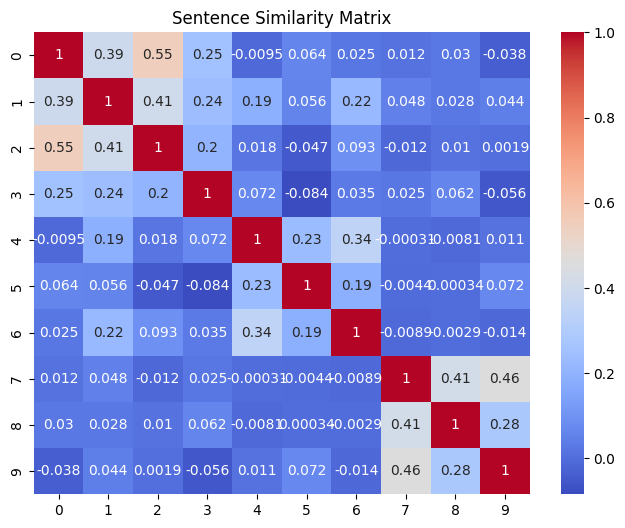

In [7]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Matrix")
plt.show()

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Sentence: The batsman scored a century in the match.
Similarity Score: 0.56114495

Sentence: The bowler delivered a fast yorker.
Similarity Score: 0.5414207

